# Capstone 2: Business Analysis with Python
## Emporium Sales Territory Analysis
### Author: Luis Alicea

This notebook analyzes in-store data for two EmporiUm sakes territories:
- **Connecticut** (Territory Maneger: Ellen Lemon, Stores 865-872)
- **New York** (Territory Maneger: See Ellefson, Stores 840-851)

The analysis covers monthly revenue, store performance, top customers, product category trends, and a marketing recommendation for next quarter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [3]:
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [4]:
products = pd.read_csv('Products.csv')
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [5]:
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [6]:
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


## Data Preparation

In [9]:
# Convert Transaction Date to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Add Year and Month columns for grouping later
store_sales['Year'] = store_sales['Transaction Date'].dt.year
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

# Strip any hidden whitespace from Territory Manager column
store_detail['Territory Manager'] = store_detail['Territory Manager'].str.strip()
store_detail['State'] = store_detail['State'].str.strip()

# Get store IDs for two territories
ct_stores = store_detail[store_detail['State'] == 'Connecticut']['Store ID'].tolist()
ny_stores = store_detail[store_detail['State'] == 'New York']['Store ID'].tolist()

print(f"Connecticut stores: {ct_stores}")
print(f"New York stores: {ny_stores}")

# Filter sales to only our two territories
ct_sales = store_sales[store_sales['Store ID'].isin(ct_stores)]
ny_sales = store_sales[store_sales['Store ID'].isin(ny_stores)]

print(f"\nConnecticut transactions: {len(ct_sales)}")
print(f"New York transactions: {len(ny_sales)}")

Connecticut stores: [865, 866, 867, 868, 869, 870, 871, 872]
New York stores: [840, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851]

Connecticut transactions: 17378
New York transactions: 31039


# Core Marketing Analysis

## Question 1: Territory Managers and Store Information
- Who are the territory managers for each assigned sales territory?
- What are the store IDs and cities for the stores in each territory?

In [10]:
# Connecticut territory info
ct_info = store_detail[store_detail['State'] == 'Connecticut'][
    ['Store Location', 'Store ID', 'Territory Manager', 'State']
    ].reset_index(drop=True)

# New York territory info
ny_info = store_detail[store_detail['State'] == 'New York'][
    ['Store Location', 'Store ID', 'Territory Manager', 'State']
    ].reset_index(drop=True)

print("=== Connecticut Territory ===")
print(f"Territory Manager: {ct_info['Territory Manager'].iloc[0]}")
print(ct_info[['Store ID', 'Store Location']])

print("\n=== New York Territory ===")
print(f"Territory Manager: {ny_info['Territory Manager'].iloc[0]}")
print(ny_info[['Store ID', 'Store Location']])

=== Connecticut Territory ===
Territory Manager: Ellen Lemon
   Store ID     Store Location
0       865         Bridgeport
1       866             Darien
2       867           Hartford
3       868  Litchfield County
4       869          New Haven
5       870         New London
6       871       Old Saybrook
7       872          Waterbury

=== New York Territory ===
Territory Manager: See Ellefson
    Store ID Store Location
0        840         Albany
1        841        Buffalo
2        842         Elmira
3        843         Ithaca
4        844         Oswego
5        845    Plattsburgh
6        846    Poestenkill
7        847      Rochester
8        848       Syracuse
9        849       Brooklyn
10       850       New York
11       851         Queens


### Findings
- Connecticut territroy is managed by **Ellen Lemon** with 8 stores across cities including Bridgeport, Hartford, New Haven, and Waterbury.
- New York territory is managed by **See Ellefson** with 12 stores across cities including Albany, Buffalo, Brooklyn, New York City, and Rochester.

## Question 2: Monthly Total Revenue by Territory
What is the monthly total revenue for in-store sales in each territory over the full period covered by the data?

In [13]:
# Monthly revenue for Connecticut
ct_monthly = ct_sales.groupby('Month')['Sale Amount'].sum().reset_index()
ct_monthly.columns = ['Month', 'CT Revenue']

# Monthly revenue for New York
ny_monthly = ny_sales.groupby('Month')['Sale Amount'].sum().reset_index()
ny_monthly.columns = ['Month', 'NY Revenue']

# Merge both into one table
monthly_revenue = pd.merge(ct_monthly, ny_monthly, on='Month', how='outer')
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

# Format as currency
monthly_revenue['CT Revenue'] = monthly_revenue['CT Revenue'].round(2)
monthly_revenue['NY Revenue'] = monthly_revenue['NY Revenue'].round(2)

print(monthly_revenue.to_string(index=False))
print(f"\nOverall CT Total: ${ct_monthly['CT Revenue'].sum():,.2f}")
print(f"Overall NY Total: ${ny_monthly['NY Revenue'].sum():,.2f}")
                            

  Month  CT Revenue  NY Revenue
2022-01    29958.25    58635.53
2022-02    25563.98    60262.97
2022-03    33995.57    57143.40
2022-04    31587.12    56880.02
2022-05    37953.48    51805.22
2022-06    32008.85    60549.86
2022-07    30656.27    56250.74
2022-08    42881.99    55052.53
2022-09    30369.64    60495.63
2022-10    43646.37    56896.98
2022-11    25950.41    58402.69
2022-12    34680.64    55006.46
2023-01    38351.45    85210.01
2023-02    53435.37    86906.65
2023-03    50828.54    79964.16
2023-04    45747.20    97173.99
2023-05    39215.78   101370.73
2023-06    39754.07    83465.90
2023-07    49592.69    90818.80
2023-08    48445.34    89422.22
2023-09    49175.79    89196.88
2023-10    45347.65    85095.72
2023-11    42683.73    79627.33
2023-12    50446.82    75904.66
2024-01    57974.76    94306.43
2024-02    49206.33    75083.70
2024-03    46044.68    99439.50
2024-04    38918.30    99105.22
2024-05    41203.81    87328.99
2024-06    48142.95    86955.71
2024-07 

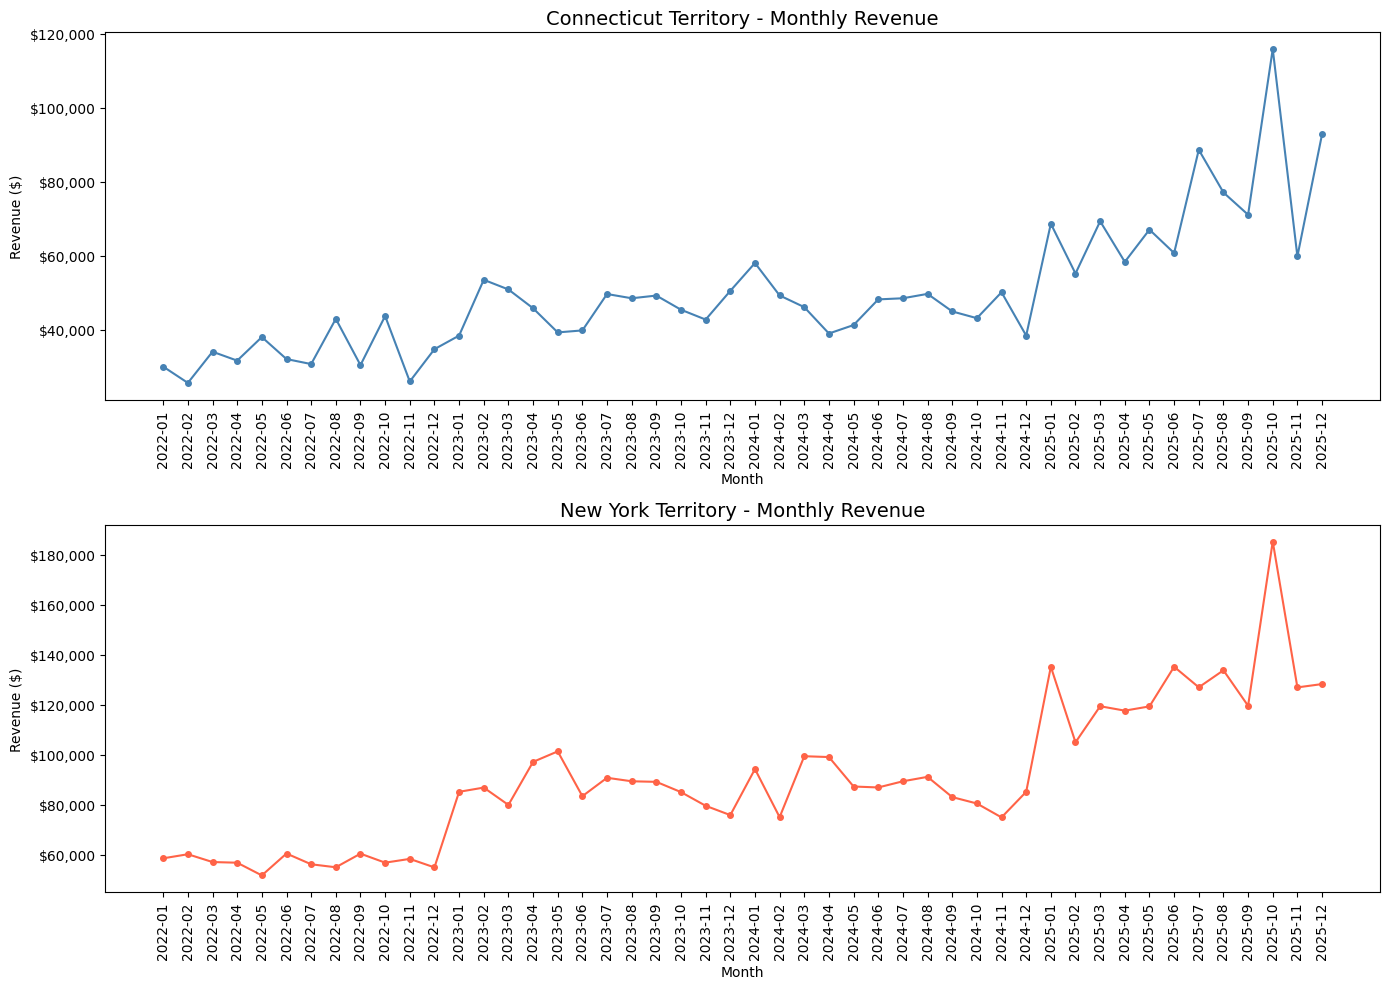

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Connecticut chart
ax1.plot(monthly_revenue['Month'], monthly_revenue['CT Revenue'],
         color='steelblue', marker='o', markersize=4)
ax1.set_title('Connecticut Territory - Monthly Revenue', fontsize=14)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)')
ax1.tick_params(axis='x', rotation=90)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# New York chart
ax2.plot(monthly_revenue['Month'], monthly_revenue['NY Revenue'],
         color='tomato', marker='o', markersize=4)
ax2.set_title('New York Territory - Monthly Revenue', fontsize=14)
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue ($)')
ax2.tick_params(axis='x', rotation=90)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### Findings
- Both territories show a clear **upward revenue trend** from 2022 through 2025.
- **Connecticut** grew from roughly 30,000 per month in early 2022 to over 110,000 in October 2025 - more than tripling over the data period.
- **New York** grew from roughly 60,000 per month in early 2022 to over 180,000 in October 2025 - also rough tripling.
- Both territories show a consistent **dip in November-December** each year, which is suprising for a retail business - this may suggest the stores are not capturing holiday shopping traffic and could be an opportunity.
- Both territories show a **late spring/early summer dip** (around May-July), possibly reflecting slower student spending outside of back-to-school season.
- **October appears to be the peak month** in both territories, likely driven by back-to-school and semester startup spending.
- New York consistently generates roughly **double the revenue** of Connecticut, which makes sense given it has 12 stores compared to Connecticut's 8.

## Question 3: Store Sales Performance Rankings
- How would you rank the sales performance of each store in each territory?
- Which are the top performing stores?

In [17]:
# Total revenue perstore for Connecticut
ct_store_revenue = ct_sales.groupby('Store ID')['Sale Amount'].agg(
    Total_Revenue='sum',
    Total_Transactions='count',
    Avg_Transaction='mean'
).round(2).reset_index()

# Merge with store names
ct_store_revenue = pd.merge(ct_store_revenue,
    store_detail[['Store ID', 'Store Location']], on='Store ID')

# Rank by total revenue
ct_store_revenue = ct_store_revenue.sort_values(
    'Total_Revenue', ascending=False).reset_index(drop=True)
ct_store_revenue.index += 1
ct_store_revenue['Total_Revenue']= ct_store_revenue['Total_Revenue'].map('${:,.2f}'.format)
ct_store_revenue['Avg_Transaction'] = ct_store_revenue['Avg_Transaction'].map('${:,.2f}'.format)

print("=== Connecticut Store Rankings ===")
print(ct_store_revenue[['Store Location', 'Store ID',
    'Total_Revenue', 'Total_Transactions', 'Avg_Transaction']].to_string())

print()

# Total revenue per store for New York
ny_store_revenue = ny_sales.groupby('Store ID')['Sale Amount'].agg(
    Total_Revenue='sum',
    Total_Transactions='count',
    Avg_Transaction='mean'
).round(2).reset_index()

# Merge with store names
ny_store_revenue = pd.merge(ny_store_revenue,
    store_detail[['Store ID', 'Store Location']], on='Store ID')

# Rank by total revenue
ny_store_revenue = ny_store_revenue.sort_values(
    'Total_Revenue', ascending=False).reset_index(drop=True)
ny_store_revenue.index += 1
ny_store_revenue['Total_Revenue'] = ny_store_revenue['Total_Revenue'].map('${:,.2f}'.format)
ny_store_revenue['Avg_Transaction'] = ny_store_revenue['Avg_Transaction'].map('${:,.2f}'.format)

print("=== New York Store Rankings ===")
print(ny_store_revenue[['Store Location', 'Store ID',
    'Total_Revenue', 'Total_Transactions', 'Avg_Transaction']].to_string())

=== Connecticut Store Rankings ===
      Store Location  Store ID Total_Revenue  Total_Transactions Avg_Transaction
1         New London       870   $331,116.76                2272         $145.74
2         Bridgeport       865   $322,100.07                2231         $144.37
3           Hartford       867   $309,592.06                2133         $145.14
4          Waterbury       872   $295,651.17                2099         $140.85
5          New Haven       869   $286,779.43                2173         $131.97
6  Litchfield County       868   $286,217.15                2127         $134.56
7             Darien       866   $283,455.62                2152         $131.72
8       Old Saybrook       871   $277,310.18                2191         $126.57

=== New York Store Rankings ===
   Store Location  Store ID Total_Revenue  Total_Transactions Avg_Transaction
1        New York       850   $621,565.02                4476         $138.87
2       Rochester       847   $607,148.21      

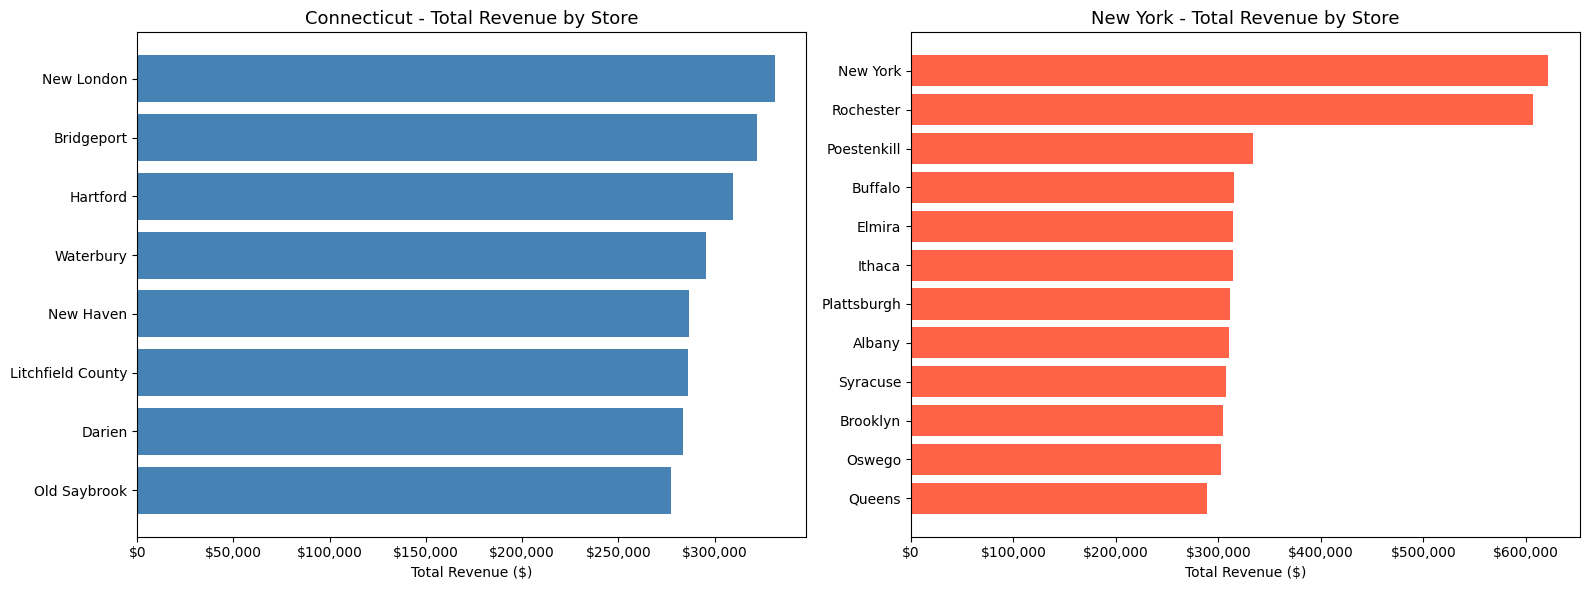

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Connecticut bar chart
ct_plot = ct_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
ct_plot = pd.merge(ct_plot, store_detail[['Store ID', 'Store Location']], on='Store ID')
ct_plot = ct_plot.sort_values('Sale Amount', ascending=True)

ax1.barh(ct_plot['Store Location'], ct_plot['Sale Amount'], color='steelblue')
ax1.set_title('Connecticut - Total Revenue by Store', fontsize=13)
ax1.set_xlabel('Total Revenue ($)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# New York bar chart
ny_plot = ny_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
ny_plot = pd.merge(ny_plot, store_detail[['Store ID', 'Store Location']], on='Store ID')
ny_plot = ny_plot.sort_values('Sale Amount', ascending=True)

ax2.barh(ny_plot['Store Location'], ny_plot['Sale Amount'], color='tomato')
ax2.set_title('New York - Total Revenue by Store', fontsize=13)
ax2.set_xlabel('Total Revenue ($)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### Findings
**Connecticut Territory:**
- **Top performers:** New London and Bridgeport lead the territory with 
  roughly 330,000 in total revenue each over the data period.
- **Bottom performers:** Old Saybrook and Darien generate the least revenue 
  at roughly 275,000 each — about 15% less than the top stores.
- Connecticut stores are relatively **closely ranked** — the gap between 
  top and bottom is not dramatic, suggesting consistent performance across the territory.

**New York Territory:**
- **Top performers:** New York City and Rochester are clear standouts, 
  each generating over 600,000 in total revenue — nearly double the bottom stores.
- **Bottom performers:** Queens and Oswego generate roughly 300,000 each 
  — significantly behind the top two stores.
- New York shows a much **wider performance gap** than Connecticut, with 
  New York City and Rochester clearly pulling ahead of the rest of the territory.
- The middle tier of stores (Poestenkill, Buffalo, Elmira, Ithaca, Plattsburgh, 
  Albany, Syracuse, Brooklyn) are closely grouped around 300,000-350,000.